In [ ]:
import numpy as np
import pandas as pd
import itertools
import subprocess
import cooler
import concurrent.futures
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from scipy import stats
from hicrep.utils import readMcool
from hicrep import hicrepSCC
from collections import Counter
import warnings
warnings.simplefilter("ignore", FutureWarning)
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform
import matplotlib.patches as mpatches
import PyComplexHeatmap as pch

In [2]:
import matplotlib as mpl

# --- Core config ---
mpl.rcParams['pdf.fonttype'] = 42     
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['svg.fonttype'] = 'none' 
mpl.rcParams['figure.dpi']   = 300    

mpl.rcParams['pdf.use14corefonts'] = False


mpl.rcParams['savefig.transparent'] = True

In [16]:
age_colors = {
    '2T': '#30123b',
    '3T': '#2a92e5',
    '1m': '#27e37b',
    '4-7m': '#f6d531',
    'adult': '#aa40fc'
}

drd_colors = {
    'DRD1': '#3B53BD',    # deep blue (D1 receptor pathway)
    'DRD2': '#E63946',    # red (D2 receptor pathway)
    'eMSN': '#fee090'     # gray (early/undifferentiated)
}

celltype_colors = {
    'Matrix': '#26D36E',      # vibrant green
    'Striosome': '#FF6B35',   # bright orange
    'Eccentric': '#9B59B6',   # purple
    'eMSN': '#fee090'         # yellow (same as original)
}

In [3]:
samples = {

    "LV_2T_Inh-MSN-eMSN":   "/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/hic_pseudobulk_raw/region_age_L3_5kb.5kb.mcool/LV_2T_Inh-MSN-eMSN.raw.mcool",
    "LV+STR+ICx+TCx_2T_Inh-MSN-eMSN":   "/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/hic_pseudobulk_raw/region_age_L3_5kb.5kb.mcool/LV+STR+ICx+TCx_2T_Inh-MSN-eMSN.raw.mcool",
    "STR_2T_Inh-MSN-eMSN":   "/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/hic_pseudobulk_raw/region_age_L3_5kb.5kb.mcool/STR_2T_Inh-MSN-eMSN.raw.mcool",

    "LV_2T_Inh-MSN-DRD1-BACH2":   "/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/hic_pseudobulk_raw/region_age_L3_5kb.5kb.mcool/LV_2T_Inh-MSN-DRD1-BACH2.raw.mcool",
    "LV+STR+ICx+TCx_2T_Inh-MSN-DRD1-BACH2":   "/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/hic_pseudobulk_raw/region_age_L3_5kb.5kb.mcool/LV+STR+ICx+TCx_2T_Inh-MSN-DRD1-BACH2.raw.mcool",
    "STR_2T_Inh-MSN-DRD1-BACH2":   "/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/hic_pseudobulk_raw/region_age_L3_5kb.5kb.mcool/STR_2T_Inh-MSN-DRD1-BACH2.raw.mcool",
    "LV_2T_Inh-MSN-DRD1-EPHA4":   "/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/hic_pseudobulk_raw/region_age_L3_5kb.5kb.mcool/LV_2T_Inh-MSN-DRD1-EPHA4.raw.mcool",
    "STR_2T_Inh-MSN-DRD1-EPHA4":   "/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/hic_pseudobulk_raw/region_age_L3_5kb.5kb.mcool/STR_2T_Inh-MSN-DRD1-EPHA4.raw.mcool",
    "LV+STR+ICx+TCx_2T_Inh-MSN-DRD1-EPHA4":   "/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/hic_pseudobulk_raw/region_age_L3_5kb.5kb.mcool/LV+STR+ICx+TCx_2T_Inh-MSN-DRD1-EPHA4.raw.mcool",

    "LV_2T_Inh-MSN-DRD2-BACH2":   "/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/hic_pseudobulk_raw/region_age_L3_5kb.5kb.mcool/LV_2T_Inh-MSN-DRD2-BACH2.raw.mcool",
    "LV+STR+ICx+TCx_2T_Inh-MSN-DRD2-BACH2":   "/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/hic_pseudobulk_raw/region_age_L3_5kb.5kb.mcool/LV+STR+ICx+TCx_2T_Inh-MSN-DRD2-BACH2.raw.mcool",
    "STR_2T_Inh-MSN-DRD2-BACH2":   "/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/hic_pseudobulk_raw/region_age_L3_5kb.5kb.mcool/STR_2T_Inh-MSN-DRD2-BACH2.raw.mcool",
    "LV_2T_Inh-MSN-DRD2-EPHA4":   "/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/hic_pseudobulk_raw/region_age_L3_5kb.5kb.mcool/LV_2T_Inh-MSN-DRD2-EPHA4.raw.mcool",
    "STR_2T_Inh-MSN-DRD2-EPHA4":   "/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/hic_pseudobulk_raw/region_age_L3_5kb.5kb.mcool/STR_2T_Inh-MSN-DRD2-EPHA4.raw.mcool",
    "LV+STR+ICx+TCx_2T_Inh-MSN-DRD2-EPHA4":   "/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/hic_pseudobulk_raw/region_age_L3_5kb.5kb.mcool/LV+STR+ICx+TCx_2T_Inh-MSN-DRD2-EPHA4.raw.mcool",

    'LV_2T_Inh-CGE-eCGE': '/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/hic_pseudobulk_raw/region_age_L3_5kb.5kb.mcool/LV_2T_Inh-CGE-eCGE.raw.mcool',
    'STR_2T_Inh-CGE-eCGE': '/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/hic_pseudobulk_raw/region_age_L3_5kb.5kb.mcool/STR_2T_Inh-CGE-eCGE.raw.mcool',
    'TCx_2T_Inh-CGE-eCGE': '/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/hic_pseudobulk_raw/region_age_L3_5kb.5kb.mcool/TCx_2T_Inh-CGE-eCGE.raw.mcool',
    'FCx_2T_Inh-CGE-eCGE': '/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/hic_pseudobulk_raw/region_age_L3_5kb.5kb.mcool/FCx_2T_Inh-CGE-eCGE.raw.mcool',


    'LV_2T_Inh-MGE-MGE': '/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/hic_pseudobulk_raw/region_age_L3_5kb.5kb.mcool/LV_2T_Inh-MGE-MGE.raw.mcool',
    'STR_2T_Inh-MGE-MGE': '/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/hic_pseudobulk_raw/region_age_L3_5kb.5kb.mcool/STR_2T_Inh-MGE-MGE.raw.mcool',
    'TCx_2T_Inh-MGE-MGE': '/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/hic_pseudobulk_raw/region_age_L3_5kb.5kb.mcool/TCx_2T_Inh-MGE-MGE.raw.mcool',
    'FCx_2T_Inh-MGE-MGE': '/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/hic_pseudobulk_raw/region_age_L3_5kb.5kb.mcool/FCx_2T_Inh-MGE-MGE.raw.mcool',
}

In [4]:
from glob import glob
import re
import pathlib

mode = 'raw'
indir = '/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/hic_pseudobulk_raw/age_L3_5kb.5kb.mcool/'
outdir = '/cndd2/hex002/Luo_Development/hic_compartment/'

In [55]:
comp = pd.read_hdf(f'{outdir}comp_{mode}_mergerawpca.hdf', key='data')

In [6]:
target_legs = {'DRD1-EPHA4':['2T_Inh-MSN-eMSN','2T_Inh-MSN-DRD1-EPHA4','3T_Inh-MSN-DRD1-EPHA4','1m_Inh-MSN-DRD1-EPHA4','4-7m_Inh-MSN-DRD1-EPHA4','adult_Inh-MSN-DRD1-EPHA4'],
               'DRD1-BACH2':['2T_Inh-MSN-eMSN','2T_Inh-MSN-DRD1-BACH2','3T_Inh-MSN-DRD1-BACH2','1m_Inh-MSN-DRD1-BACH2','4-7m_Inh-MSN-DRD1-BACH2','adult_Inh-MSN-DRD1-BACH2'],
               'DRD2-EPHA4':['2T_Inh-MSN-eMSN','2T_Inh-MSN-DRD2-EPHA4','3T_Inh-MSN-DRD2-EPHA4','1m_Inh-MSN-DRD2-EPHA4','4-7m_Inh-MSN-DRD2-EPHA4','adult_Inh-MSN-DRD2-EPHA4'],
               'DRD2-BACH2':['2T_Inh-MSN-eMSN','2T_Inh-MSN-DRD2-BACH2','3T_Inh-MSN-DRD2-BACH2','1m_Inh-MSN-DRD2-BACH2','4-7m_Inh-MSN-DRD2-BACH2','adult_Inh-MSN-DRD2-BACH2'],
               'DRD1-eccentric':['2T_Inh-MSN-eMSN','2T_Inh-MSN-DRD1-eccentric-CASZ1','3T_Inh-MSN-DRD1-eccentric-CASZ1','1m_Inh-MSN-DRD1-eccentric-CASZ1','4-7m_Inh-MSN-DRD1-eccentric-CASZ1','adult_Inh-MSN-DRD1-eccentric-CASZ1'],
}

In [8]:
all_legs = list(itertools.chain.from_iterable(target_legs.values()))
all_legs = [leg for leg in all_legs if re.search(r'(2T|3T|1m|4-7m|adult)', leg)]
all_legs = list(set(all_legs))

In [56]:
comp_sub = comp.loc[:, all_legs]

In [11]:
from PyComplexHeatmap import HeatmapAnnotation, DotClustermapPlotter, anno_label, anno_simple, AnnotationBase
import matplotlib.pyplot as plt

In [12]:
corr = comp_sub.corr(method='pearson')
corr.index = corr.index.str.replace('EPHA4', 'Matrix', regex=False)
corr.index = corr.index.str.replace('BACH2', 'Striosome', regex=False)
corr.index = corr.index.str.replace('-CASZ1', '', regex=False)

corr.columns = corr.columns.str.replace('EPHA4', 'Matrix', regex=False)
corr.columns = corr.columns.str.replace('BACH2', 'Striosome', regex=False)
corr.columns = corr.columns.str.replace('-CASZ1', '', regex=False)

# Create annotation dataframe
annotations = pd.DataFrame(index=corr.columns)

# Extract Age (2T, 3T, 1m, 4-7m, adult)
annotations['Age'] = annotations.index.str.extract(r'(2T|3T|1m|4-7m|adult)', expand=False)

# Extract DRD subtype (DRD1, DRD2)
annotations['DRD_Type'] = annotations.index.str.extract(r'(DRD1|DRD2|MGE|CGE)', expand=False)
annotations['DRD_Type'] = annotations['DRD_Type'].fillna('eMSN')  # Fill eMSN for early MSN without DRD type


# Extract Cell Type (Matrix, Striosome, eccentric, eMSN)
def extract_celltype(name):
    if 'Matrix' in name:
        return 'Matrix'
    elif 'Striosome' in name:
        return 'Striosome'
    elif 'eccentric' in name:
        return 'Eccentric'
    elif 'eMSN' in name:
        return 'eMSN'
    else:
        return 'Other'

annotations['Cell_Type'] = annotations.index.map(extract_celltype)

/tmp/ipykernel_3490645/4037423497.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = plt.cm.get_cmap('cividis')


Starting plotting HeatmapAnnotations


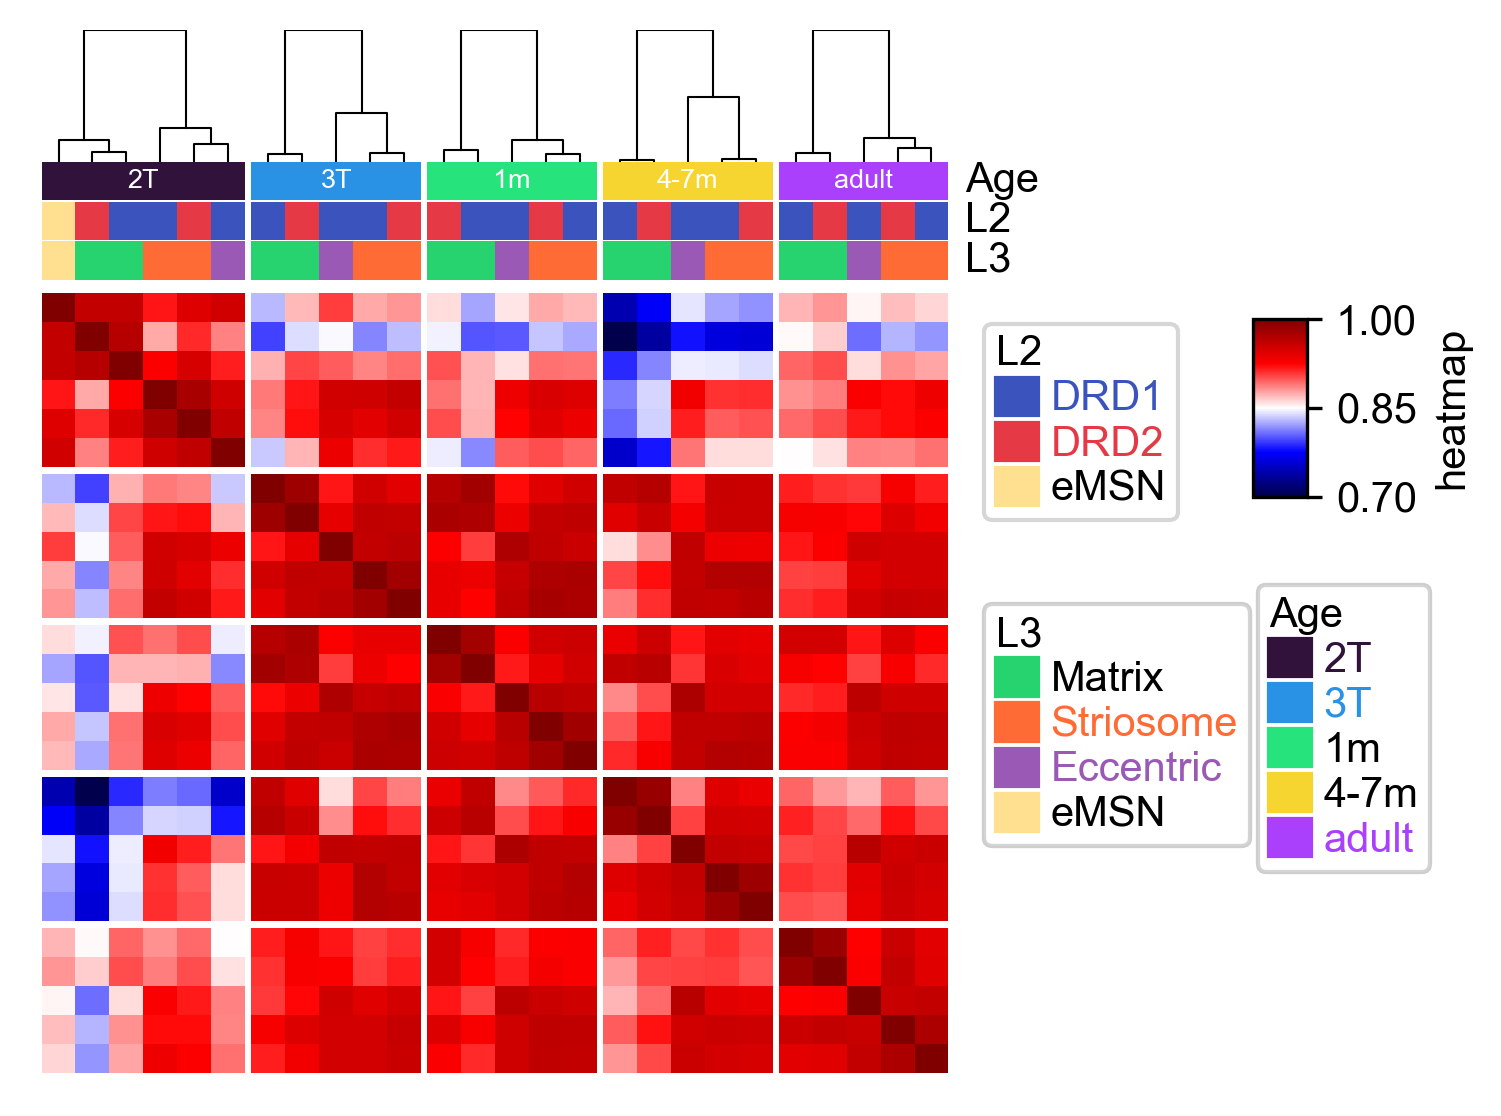

In [17]:
import matplotlib.colors as mcolors
N = 6

# --- Step 2. Sample colors from cividis ---
base = plt.cm.get_cmap('cividis')
colors = base(np.linspace(0, 1, N))

# --- Step 3. Define boundaries for the data range ---
# Example: for correlation matrix in [0.8, 1.0]
vmin = 0.7
vmax = 1.0
bounds = np.linspace(vmin, vmax, N+1)

# --- Step 4. Construct cmap + norm (required for discrete mapping) ---
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(bounds, cmap.N)


col_ha = pch.HeatmapAnnotation(
    Age=pch.anno_simple(
        annotations['Age'],
        colors=age_colors,
        add_text=True,
        legend=True
    ),
    L2=pch.anno_simple(
        annotations['DRD_Type'],
        colors=drd_colors,
        add_text=False,
        legend=True
    ),
    L3=pch.anno_simple(
        annotations['Cell_Type'],
        colors=celltype_colors,
        add_text=False,
        legend=True
    ),
    axis=1,
    height=20
)
plt.figure(figsize=(4, 4))
age_order = ['2T','3T','1m','4-7m','adult']

annotations['Age_cat'] = pd.Categorical(
    annotations['Age'],
    categories=age_order,
    ordered=True
)

col_split = annotations['Age'].map(lambda x: age_order.index(x))
row_split = annotations['Age'].map(lambda x: age_order.index(x))

cm = pch.ClusterMapPlotter(
    data=corr,
    top_annotation=col_ha,

    row_split=annotations.Age,
    col_split=annotations.Age,

    col_split_order=age_order,
    row_split_order=age_order,
    # row_split_order='cluster_within_groups',

    row_split_gap=0.5,
    col_split_gap=0.5,

    row_cluster=True,
    col_cluster=True,

    show_rownames=False,
    show_colnames=False,

    col_dendrogram=True,

    # cmap=cmap,
    
    # norm=norm,
    # vmin=vmin,
    # vmax=vmax,


    cmap='seismic',
    vmin=vmin,              # match your seaborn heatmap
    vmax=vmax,

    rasterized=True,
    legend_anchor="ax_heatmap",
    legend_vpad=5,
    verbose=False
)

# plt.savefig('/cndd2/hex002/Luo_Development/hic_compartment/figures/MSN_compartment_correlation_msn_subtypes.svg', dpi=400, bbox_inches='tight',transparent=False)
plt.show()

## Variance Explained Analysis

In [ ]:
print(f"Compartment score matrix shape: {comp_sub.shape}")
print(f"Genomic bins: {comp_sub.shape[0]}, Samples: {comp_sub.shape[1]}")

# Create annotations for comp_sub columns (matching the samples)
annotations_comp = pd.DataFrame(index=comp_sub.columns)

# Extract Age (2T, 3T, 1m, 4-7m, adult)
annotations_comp['Age'] = annotations_comp.index.str.extract(r'(2T|3T|1m|4-7m|adult)', expand=False)

# Extract DRD subtype (DRD1, DRD2)
annotations_comp['DRD_Type'] = annotations_comp.index.str.extract(r'(DRD1|DRD2)', expand=False)
annotations_comp['DRD_Type'] = annotations_comp['DRD_Type'].fillna('eMSN')

# Extract Cell Type
def extract_celltype(name):
    if 'EPHA4' in name:
        return 'Matrix'
    elif 'BACH2' in name:
        return 'Striosome'
    elif 'eccentric' in name:
        return 'Eccentric'
    elif 'eMSN' in name:
        return 'eMSN'
    else:
        return 'Other'

annotations_comp['Cell_Type'] = annotations_comp.index.map(extract_celltype)

# Extract Region
def extract_region(name):
    parts = name.split('_')
    if len(parts) > 0:
        return parts[0]
    return 'Unknown'


Compartment score matrix shape: (24790, 26)
Genomic bins: 24790, Samples: 26


In [58]:
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

# ----------------------------------------------------------------------
# 1. Align annotations with samples in comp_sub
# ----------------------------------------------------------------------
annotations_comp = annotations_comp.loc[comp_sub.columns]  # ensure same order

# Transpose compartment matrix so each column is a genomic bin
Y = comp_sub.T.values    # shape: (n_samples, n_bins)
n_samples, n_bins = Y.shape

print(f"Transposed compartment matrix shape: {Y.shape}")

# Build dataframe with predictors only once
predictors_df = annotations_comp[['Age', 'DRD_Type', 'Cell_Type']].copy()

# ----------------------------------------------------------------------
# 2. Function: run Type-II ANOVA and compute eta-squared for each factor
# ----------------------------------------------------------------------
def anova_eta_squared(y, predictors):
    """
    Perform Type-II ANOVA on one genomic bin.
    Returns eta-squared for each factor: SS_effect / SS_total
    """
    df = predictors.copy()
    df['y'] = y

    # Fit OLS model with categorical predictors
    model = smf.ols("y ~ C(Age) + C(DRD_Type) + C(Cell_Type)", data=df).fit()

    # Type-II ANOVA
    anova = anova_lm(model, typ=2)

    # eta² = SS_effect / SS_total
    ss_total = anova['sum_sq'].sum()
    eta_sq = anova['sum_sq'] / ss_total

    return eta_sq

# ----------------------------------------------------------------------
# 3. Loop across genomic bins and collect variance explained
# ----------------------------------------------------------------------
eta_list = []

for i in range(n_bins):
    y = Y[:, i]
    if np.std(y) < 1e-10:
        # Skip invariant bins (cannot compute ANOVA)
        continue

    eta_sq = anova_eta_squared(y, predictors_df)
    eta_list.append(eta_sq)

# Convert to DataFrame
eta_df = pd.DataFrame(eta_list)
eta_df.columns = ["Age", "DRD Type (L2)", "Cell Type (L3)", "Residual"]

# ----------------------------------------------------------------------
# 4. Compute mean variance explained across all bins
# ----------------------------------------------------------------------
mean_eta = eta_df.mean() * 100     # convert to %
print("\n===== Mean Variance Explained (η²) Across Compartment Bins =====")
print(mean_eta)

Transposed compartment matrix shape: (26, 24790)

===== Mean Variance Explained (η²) Across Compartment Bins =====
Age               39.306565
DRD Type (L2)      6.234477
Cell Type (L3)    23.882721
Residual          30.576237
dtype: float64


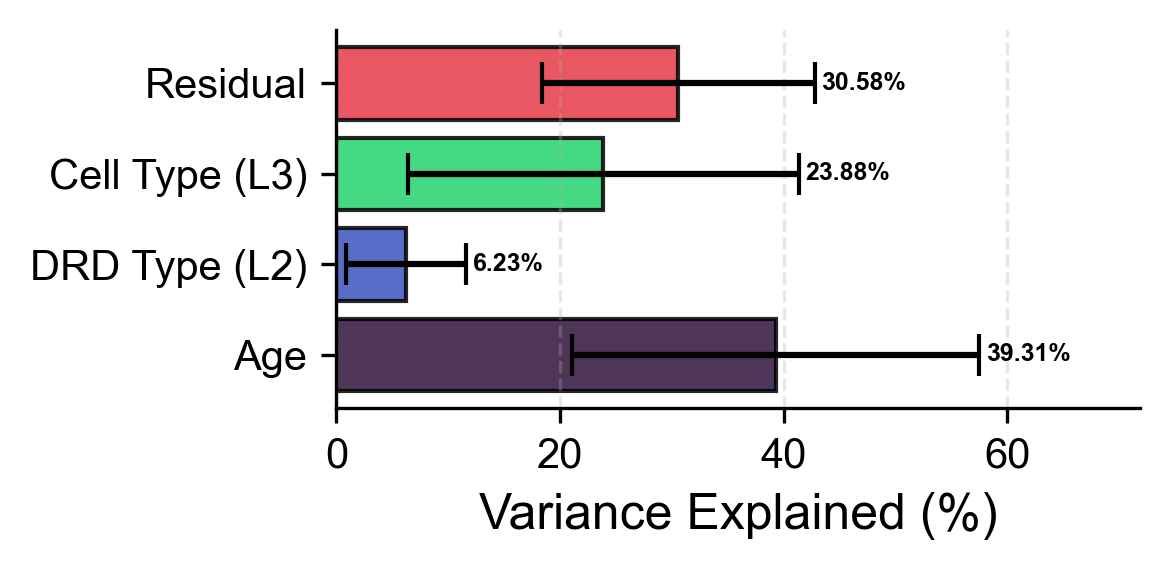

In [ ]:
eta_mean = eta_df.mean() * 100     # convert to %
eta_se   = eta_df.sem() * 100      # SE in %
eta_sd   = eta_df.std() * 100      # SD in %

factors_list = eta_mean.index.tolist()
mean_values = eta_mean.values
se_values = eta_se.values
sd_values = eta_sd.values

# --- Colors (your palette) ---
colors_bar = ['#30123b', '#3B53BD', '#26D36E', '#E63946']  

# --- Plot ---
fig, ax = plt.subplots(figsize=(4, 2))

bars = ax.barh(
    y=factors_list,
    width=mean_values,
    xerr=sd_values,
    color=colors_bar,
    alpha=0.85,
    capsize=5,
    linewidth=1,
    edgecolor='black'
)

# Labels
ax.set_xlabel("Variance Explained (%)", fontsize=12)
# ax.set_title("Imputed Matrix", fontsize=13, fontweight='bold')

# Limit
ax.set_xlim(0, max(mean_values + sd_values) * 1.25)

# Add % labels to right of bars
for i, (m, sd) in enumerate(zip(mean_values, sd_values)):
    ax.text(
        m + sd + 0.6,   # offset by SD so label is past the error bar
        i,
        f"{m:.2f}%",
        va='center',
        fontsize=6,
        fontweight='bold'
    )

# Clean look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
# plt.savefig('/cndd2/hex002/Luo_Development/hic_compartment/figures/MSN_compartment_variance_explained_raw_model.pdf', dpi=300, bbox_inches='tight')
plt.show()